# DAY2 — Batch3 추가 테스트

Batch1 개발 29셀로 이미 학습한 CV 선택 ElasticNet과 분산 1개 모델을 그대로 적용한다. 두 모델은 Batch3 점수를 보기 전에 고정했으며 **재학습·재튜닝·모델 재선정은 없다.** 원본 46셀 중 수명 결측 2셀을 제외한 44셀을 평가한다.

Batch3는 EDA에 사용됐으므로 완전히 보지 않은 데이터라고 표현하지 않는다.

[전체 DAY2 보고서](../outputs/day2/DAY2_REPORT.md) · [Batch3 상세 보고서](../outputs/day2/DAY2_BATCH3_TEST.md)

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if not (ROOT / "src/day2_batch3.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/day2_batch3.py").is_file()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.day2_batch3 import main
main()  # 완료 결과가 있으면 저장값 재사용; 최초 실행에서만 고정 모델 평가
OUT = ROOT / "outputs/day2/batch3_test"

Saved Batch3 test exists; no repeated training or scoring.
              candidate               evaluation  n  mape_pct     mae    rmse    r2  bias_cycles  underprediction_n
S3_elasticnet_0.001_0.5           Test (Batch 2) 39    37.138 197.703 217.063 0.021      177.863                  3
S3_elasticnet_0.001_0.5           Test (Batch 3) 44    15.099 194.635 296.242 0.088     -182.139                 37
S3_elasticnet_0.001_0.5 Valid (Batch 1 Hold-out)  7     8.923  71.667  90.773 0.728        6.049                  2
              S0_linear           Test (Batch 2) 39    28.685 142.757 159.825 0.469      127.799                  4
              S0_linear           Test (Batch 3) 44    12.087 150.220 250.897 0.346      -85.663                 27
              S0_linear Valid (Batch 1 Hold-out)  7    10.728  88.270  96.290 0.694      -18.454                  4


## 1. 입력·제외 기준 확인

원본의 초기 특징과 저장 입력을 대조했다. 학습 범위 밖 값이나 큰 예측 오차를 이유로 셀을 제거하지 않았다.

In [2]:
audit = pd.read_csv(OUT / "input_audit.csv")
display(audit.groupby(["included", "exclusion_reason"]).size().rename("셀 수").to_frame())
assert len(audit) == 46 and audit.included.sum() == 44
assert audit.loc[audit.included, ["finite_model_inputs", "input_horizon_ok"]].all().all()
display(pd.read_csv(OUT / "range_diagnostics.csv").round(5))

,,셀 수
included,exclusion_reason,
False,missing_raw_target,2
True,included,44


,feature,development_min,development_max,batch3_min,batch3_max,below_development_n,above_development_n
0,log10_delta_Q_var,-4.14690,-3.35034,-5.09886,-3.45166,24,0
1,delta_Q_min,-0.06472,-0.02369,-0.05783,-0.00561,0,19
2,qd_initial_median,1.05943,1.09827,1.04910,1.07705,7,0
3,qd_fraction_change,-0.01090,0.00118,-0.01560,0.00030,3,0
4,early_drop_per100,-0.00133,0.01527,-0.00002,0.02038,0,3
5,cycle_life,534.00000,1054.00000,541.00000,1935.00000,0,17


## 2. 성능표와 배치 비교

MAPE와 사이클 단위 MAE·RMSE를 함께 본다. 현재 분산 모델은 29셀 학습 모델로, 과거 28셀 모델의 Batch2 26.19%와 구분한다.

,구분,비교,MAPE (%),비고
0,Train (Batch 1 CV),,5.683,기존 프로토콜 CV 평균; 재학습하지 않음
1,Valid (Batch 1 Hold-out),,8.923,기존 7셀·4프로토콜
2,Test (Batch 2),,37.138,기존 39셀 평가; 재계산하지 않음
3,,Gap (Train-Valid),3.241,Valid − CV; %p
4,,Gap (Valid-Test),28.215,Batch2 − Valid; %p
5,,Gap (Target-Test),28.038,Batch2 − 참고값 9.1; %p
6,Test (Batch 3),,15.099,44셀; 같은 고정 모델의 추가 평가
7,,Gap (Batch2-Batch3),-22.039,Batch3 − Batch2; (+)이면 Batch3 오차 증가; %p
8,,Gap (Target-Test),5.999,Batch3 − 과제 공통 참고값 9.1; 논문의 Batch3 목표치 아님


,candidate,evaluation,n,mape_pct,mae,rmse,r2,bias_cycles,underprediction_n
0,S3_elasticnet_0.001_0.5,Test (Batch 2),39,37.138,197.703,217.063,0.021,177.863,3
1,S3_elasticnet_0.001_0.5,Test (Batch 3),44,15.099,194.635,296.242,0.088,-182.139,37
2,S3_elasticnet_0.001_0.5,Valid (Batch 1 Hold-out),7,8.923,71.667,90.773,0.728,6.049,2
3,S0_linear,Test (Batch 2),39,28.685,142.757,159.825,0.469,127.799,4
4,S0_linear,Test (Batch 3),44,12.087,150.220,250.897,0.346,-85.663,27
5,S0_linear,Valid (Batch 1 Hold-out),7,10.728,88.270,96.290,0.694,-18.454,4


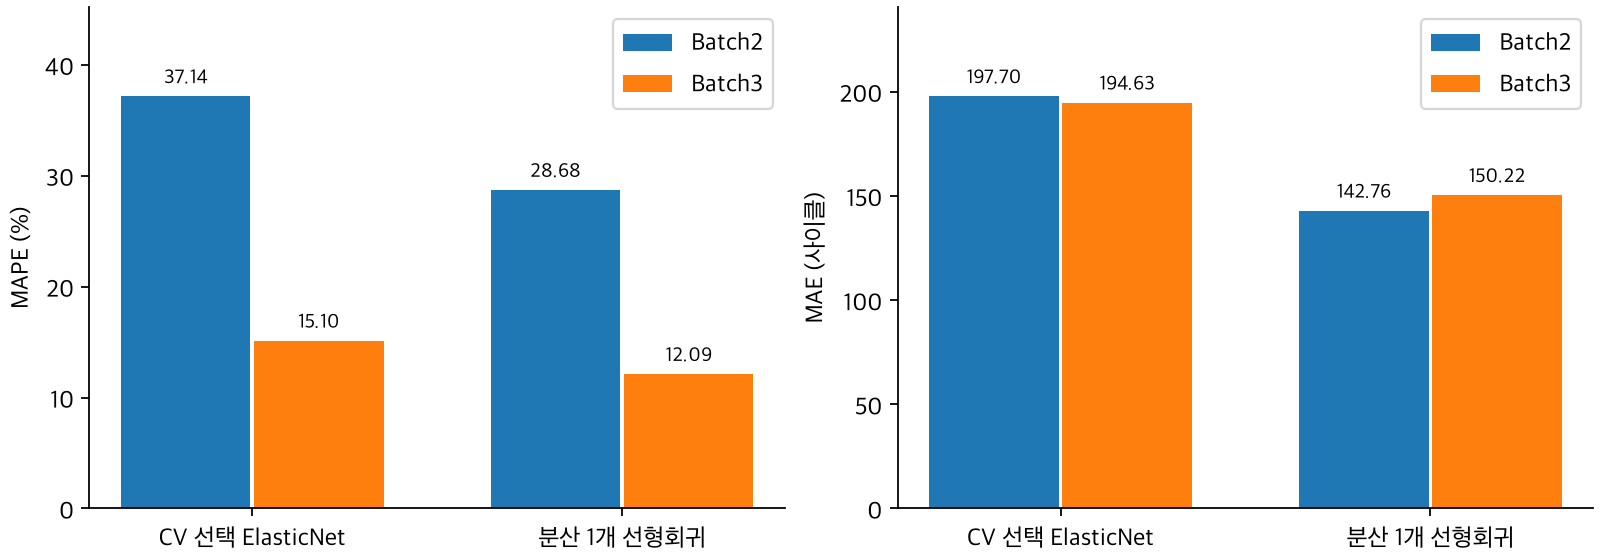

In [3]:
display(pd.read_csv(OUT / "performance_reporting.csv").round(3).fillna(""))
display(pd.read_csv(OUT / "evaluation_metrics.csv").round(3))
display(Image(filename=str(OUT / "batch_comparison.png")))

## 3. 장수명 외삽

학습 최대 수명 1,054사이클을 넘는 17셀에서 ElasticNet은 전부 과소예측했다. 범위 안 27셀의 MAPE는 ElasticNet 7.57%, 분산 모델 8.71%로 순서가 반대다. 추가 특징의 효과가 수명 구간에 따라 달라졌다.

,candidate,segment,n,mape_pct,mae,bias_cycles,underprediction_n
0,S3_elasticnet_0.001_0.5,within training life range,27,7.566,68.436,-48.073,20
1,S3_elasticnet_0.001_0.5,above training maximum,17,27.064,395.069,-395.069,17
2,S0_linear,within training life range,27,8.706,73.094,31.496,11
3,S0_linear,above training maximum,17,17.457,272.715,-271.738,16


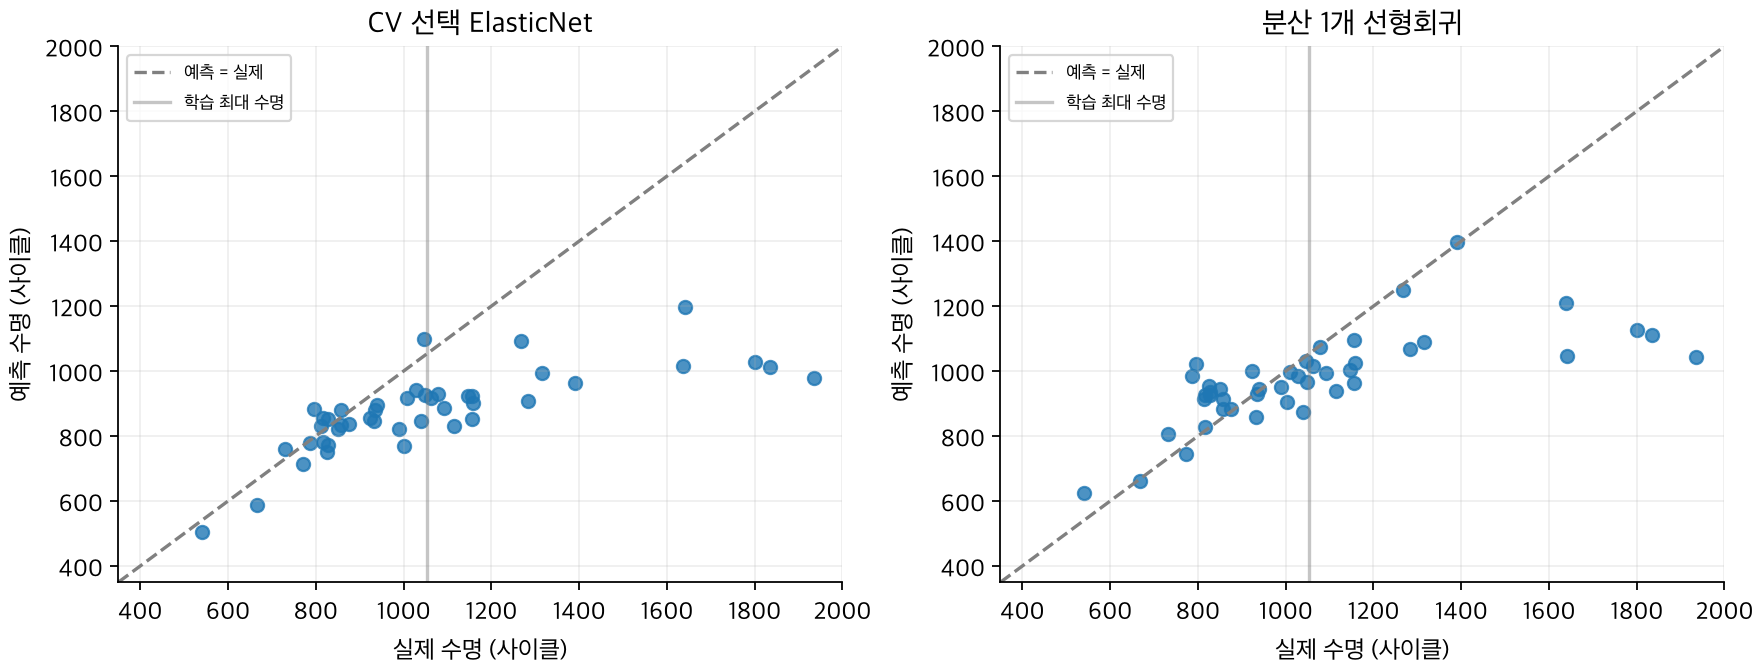

In [4]:
display(pd.read_csv(OUT / "life_segments.csv").round(3))
display(Image(filename=str(OUT / "predictions.png")))

## 결론

CV 선택 ElasticNet의 Batch3 MAPE는 **15.10%**, 분산 기준 모델은 **12.09%**였다. 긴 수명에서 과소예측이 남았고, Batch2보다 낮은 MAPE를 모든 오차의 개선으로 해석할 수 없다. 이 추가 평가로 모델을 바꾸거나 재튜닝하지 않는다.